# Loading

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [92]:
BASEDIR = "../LOGS"

runs = pd.read_csv(os.path.join(BASEDIR, "runs.csv"))
search_info = pd.read_csv(os.path.join(BASEDIR, "search_settings.csv"))
dataset_info = pd.read_csv(os.path.join(BASEDIR, "dataset_settings.csv"))
index_info = pd.read_csv(os.path.join(BASEDIR, "index_settings.csv"))

# Join the three settings dataframes on dataset_file
info = search_info.join(dataset_info.set_index('dataset_file'), on='dataset_file', how='left', rsuffix='_dataset')
info = info.join(index_info.set_index('index_file'), on='index_file', how='left', rsuffix='_index')

# Join the two dataframes where runs['settings_id'] is the id of the search settings
df = pd.merge(runs, info, left_on='settings_id', right_on='id', how='left', suffixes=('_run', '_settings'))

print(df.columns)

df

Index(['id_run', 'settings_id', 'query_id', 'query_length', 'query_channels',
       'result_set_ts_indices', 'result_set_ts_positions',
       'result_set_distances', 'num_leaves_visited', 'num_nodes_visited',
       'num_ts_examined', 'total_time_s', 'first_layer_time_s',
       'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s',
       'id_settings', 'index_file', 'dataset_file', 'ffts_file', 'query_file',
       'num_queries', 'query_type', 'r_range_r', 'knn_k', 'exact',
       'normalized', 'search_method', 'distance_measure', 'early_abandoning',
       'id_dataset', 'series_length', 'num_channels', 'num_series', 'sd',
       'source_csvs', 'low_sd_len', 'id_index', 'dataset_file_index',
       'ffts_file_index', 'l_min', 'l_max', 'normalized_index', 'index_type',
       'segment_length', 'pos_per_env', 'first_layer_num_bits',
       'leaf_capacity', 'breakpoint_strategy', 'split_strategy',
       'min_num_bits_on_tie', 'num_bits_limit', 'indexing_time_s',
       'fft_c

,id_run,settings_id,query_id,query_length,query_channels,result_set_ts_indices,result_set_ts_positions,result_set_distances,num_leaves_visited,num_nodes_visited,...,segment_length,pos_per_env,first_layer_num_bits,leaf_capacity,breakpoint_strategy,split_strategy,min_num_bits_on_tie,num_bits_limit,indexing_time_s,fft_calc_time_s
0,0,0,0,1024,1;1;1;1;1,2,430,0.193788,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,1024,1;1;1;1;1,2,430,0.193788,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,1,2048,1;1;1;1;1,5,0,42.388335,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,1,2048,1;1;1;1;1,5,0,42.388335,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,0,2,1024,1;1;1;1;1,16,808,6437.203910,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,1435,15,85,512,1;1;1;1,944,502,0.057854,183,189,...,32.0,522.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,6.698123,1.248521
2156,1436,15,86,512,1;1;1;1,946,183,0.049443,184,190,...,32.0,522.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,6.698123,1.248521
2157,1437,15,87,768,1;1;1;1,948,112,0.035732,172,178,...,32.0,522.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,6.698123,1.248521
2158,1438,15,88,768,1;1;1;1,986,144,0.031104,151,157,...,32.0,522.0,1.0,64.0,equiprobable,entropy_maximizing,1.0,12.0,6.698123,1.248521


In [93]:
# Infer necessary columns
ALGOS = ['BRUTE_FORCE', 'MASS', 'MULISSE', 'MULISSE_ED']

# Algorithm -- dependent on combinations of search method and distance measure
def get_algorithm(row):
    search_method = row.search_method
    distance_measure = row.distance_measure
    ffts_precomputed = not pd.isna(row.ffts_file)
    # early_abandon = row.early_abandoning
    early_abandon = True

    if 'scan' in search_method and distance_measure == 'ed' and not ffts_precomputed and early_abandon:
        return 'BRUTE_FORCE'
    elif 'scan' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MASS'
    elif 'isax' in search_method and distance_measure == 'ed' and early_abandon:
        return 'MULISSE_ED'
    elif 'isax' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MULISSE'
    else:
        return np.nan
    
df['algorithm'] = df.apply(get_algorithm, axis=1)

df['dataset'] = df.dataset_file.str.extract(r'(\w+).bin')
df['dataset'] = df.dataset.str.split("_").str[0]

df['num_query_channels'] = df.query_channels.str.count('1')

df[['algorithm', 'dataset', 'query_channels', 'num_query_channels', 'num_series', 'series_length', 'num_channels']]

,algorithm,dataset,query_channels,num_query_channels,num_series,series_length,num_channels
0,MASS,stocks,1;1;1;1;1,5,1000,2048,5
1,MASS,stocks,1;1;1;1;1,5,1000,2048,5
2,MASS,stocks,1;1;1;1;1,5,1000,2048,5
3,MASS,stocks,1;1;1;1;1,5,1000,2048,5
4,MASS,stocks,1;1;1;1;1,5,1000,2048,5
...,...,...,...,...,...,...,...
2155,MULISSE,weather,1;1;1;1,4,1000,1024,4
2156,MULISSE,weather,1;1;1;1,4,1000,1024,4
2157,MULISSE,weather,1;1;1;1,4,1000,1024,4
2158,MULISSE,weather,1;1;1;1,4,1000,1024,4


# Test

In [97]:
view = df[
    (df.algorithm.isna() == False) &
    (df.dataset.isin(['weather', 'stocks', 'rwalk'])) &
    (df.num_channels == df.num_query_channels) &
    (df.num_series == 1000) &
    (df.series_length == 2048) &
    (df.query_length.isin([1536, 1792, 2048])) &
    ((~df.algorithm.str.contains("MULISSE")) | (df.l_min == 1536)) &
    True
]

view.groupby(['algorithm', 'dataset', 'query_length']).size().unstack()

query_length       1536  1792  2048
algorithm dataset                  
MASS      rwalk      30    30    30
          stocks    120    60   120
          weather   120    60   120
MULISSE   rwalk      30    30    30
          stocks     60    60    60
          weather    60    60    60

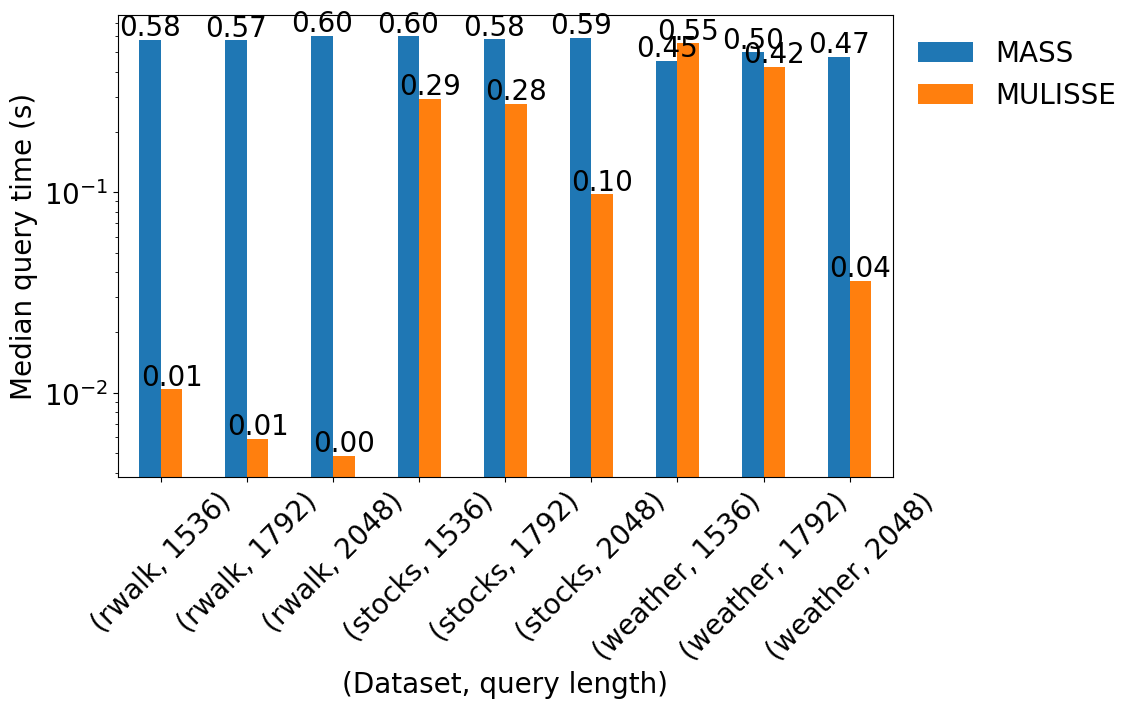

In [98]:
# Set fontsize of everything
plt.rcParams.update({'font.size': 20})

fig, ax = plt.subplots(figsize=(10, 6))

bar_plot = view.groupby(['dataset', 'query_length', "algorithm"]).total_time_s.median().unstack().plot(kind='bar', ax=ax)

# Rotate xticks
plt.xticks(rotation=45)

ax.set_ylabel("Median query time (s)")
ax.set_xlabel("(Dataset, query length)")

ax.legend(title=None, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax.set_yscale("log")

# Add annotations
for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.2f'),
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha = 'center', va = 'center',
                      xytext = (0, 9),
                      textcoords = 'offset points')
    
# ax.set_ylim(0.01, 1)

# plt.tight_layout()

In [99]:
view.groupby(['algorithm', 'query_length']).num_ts_examined.median().unstack()

query_length,1536,1792,2048
algorithm,,,
MASS,1000.0,1000.0,1000.0
MULISSE,467.0,465.0,74.0
